# 03 · Execution time

**Question.** How long did each of the 480 pipeline runs take, and which settings go with longer runs?

**Reviewer comment.** None.

**Reads.** `data/derived/sets_dict.parquet` (only to know which 480 runs the study holds), `data/reference/TestCases.csv` (the columns `ElapsedTime` and `Node`) and `data/reference/sequencing_yield.csv` (total bases and tumour/normal coverage per sample, from Table 1 of the manuscript). It never reads `data/raw/`; no VCF is parsed and no variant is used.

**Produces** (`results/03_execution_time/`):
- `tables/elapsed_time.csv`: one row per run: its settings, compute node, `ElapsedTime` as recorded (`H:MM:SS`) and `elapsed_seconds`.
- `tables/elapsed_time_by_setting.csv`: for every level of every setting, and for each combination of trimming and base recalibration, the number of runs and the mean, median, minimum and maximum elapsed seconds. This table is not in the legacy notebook.
- `figures/elapsed_time_by_run`: one point per run, one panel per sample, callers along the x axis; colour is the mapper, the marker gives the combination "Trimming, BaseRecalibration": a circle is trimming yes and a triangle no, a filled marker is base recalibration yes and a hollow one no. The panels are ordered by total sequencing yield, left to right, and each carries its total bases and tumour/normal coverage. Those annotations come from Table 1, not from anything computed here.

**Legacy.** The legacy notebook built `df_timeTable` from the run metadata and drew a scatter figure of it; it computed no statistics. Parity reproduces `df_timeTable.csv` for every run.

**Caveat.** `ElapsedTime` is the recorded wall-clock time. The runs used many different compute nodes in two environments, and the node is not controlled, so the comparisons by setting are descriptive.

**Does not.** Test differences between settings (no ANOVA or t-test: there is none in the legacy notebook), or draw the legacy interactive figure.

## Imports

In [46]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from swb import audit, config, io, viz

## Config

In [47]:
OUT = config.results_dir("03_execution_time")
STAGE = audit.Stage(OUT / ".staging")

EXPECTED_RUNS = 480
LEVELS = config.FACTOR_LEVELS
TRIM_RECAL = "isTrimmed, baseRecalibration"  # the four combinations, as in the figure legend: trimming, then base recalibration

## Load + validate

In [48]:
assert config.SETS_PARQUET.exists(), "run 01_variant_sets first"
sets = io.load_sets(config.SETS_PARQUET)  # used only for the run keys
assert len(sets) == EXPECTED_RUNS, len(sets)

meta = pd.read_csv(config.METADATA_CSV)
assert list(meta.columns) == config.METADATA_COLUMNS, list(meta.columns)
runs = io.study_runs(meta, sets, LEVELS, rename=config.METADATA_RENAME)
assert len(runs) == EXPECTED_RUNS, len(runs)
assert runs[["Node", "ElapsedTime"]].notna().all().all(), "a run without a node or an elapsed time"
runs["elapsed_seconds"] = io.hms_to_seconds(runs["ElapsedTime"]).to_numpy()
runs[TRIM_RECAL] = runs["isTrimmed"] + ", " + runs["baseRecalibration"]
assert (runs["elapsed_seconds"] > 0).all(), "a run with no elapsed time"

# Sequencing yield and coverage per sample (manuscript Table 1); panel order = increasing yield
yield_table = io.sequencing_yield(config.SEQUENCING_YIELD_CSV, LEVELS["Sample"])
panel_order = yield_table["Sample"].tolist()
panel_notes = viz.yield_panel_notes(yield_table)

print("{} runs, {:.0f} hours in all, {} compute nodes".format(
    len(runs), runs["elapsed_seconds"].sum() / 3600, runs["Node"].nunique()))

480 runs, 1827 hours in all, 83 compute nodes


## Analysis

In [49]:
time_table = runs.reset_index()[["run", "Sample", "Environment", "isTrimmed", "baseRecalibration", "Mapper",
                                 "VariantCaller", "Duplicates", "Node", "ElapsedTime", "elapsed_seconds"]]
assert len(time_table) == EXPECTED_RUNS and time_table["run"].is_unique
time_table.head()

,run,Sample,Environment,isTrimmed,baseRecalibration,Mapper,VariantCaller,Duplicates,Node,ElapsedTime,elapsed_seconds
0,2,EA,Altay + COSAP,YES,YES,BWA,Mutect,MARK,a047,07:15:00,26100
1,8,EA,Altay + COSAP,NO,NO,BWA,Mutect,MARK,a047,06:12:47,22367
2,14,EA,Altay + COSAP,YES,NO,BWA,Mutect,MARK,a047,05:48:51,20931
3,20,EA,Altay + COSAP,NO,YES,BWA,Mutect,MARK,a047,07:44:08,27848
4,26,EA,Altay + COSAP,YES,YES,BOWTIE,Mutect,MARK,a078,07:36:41,27401


In [50]:
by_setting = pd.concat([
    runs.groupby(setting)["elapsed_seconds"]
        .agg(n_runs="size", mean_seconds="mean", median_seconds="median", min_seconds="min", max_seconds="max")
        .reset_index().rename(columns={setting: "level"}).assign(setting=setting)
    for setting in list(LEVELS) + [TRIM_RECAL]], ignore_index=True)[
    ["setting", "level", "n_runs", "mean_seconds", "median_seconds", "min_seconds", "max_seconds"]]
assert (by_setting.groupby("setting")["n_runs"].sum() == EXPECTED_RUNS).all()
by_setting.assign(mean_hours=(by_setting["mean_seconds"] / 3600).round(2))[["setting", "level", "n_runs", "mean_hours"]]

,setting,level,n_runs,mean_hours
0,Sample,EA,96,4.96
1,Sample,FD,96,2.56
2,Sample,IL,96,5.68
3,Sample,LL,96,1.83
4,Sample,NC,96,4.00
5,Environment,Altay + COSAP,240,3.72
6,Environment,Uhem + COSAP,240,3.89
7,isTrimmed,NO,240,4.08
8,isTrimmed,YES,240,3.54
9,baseRecalibration,NO,240,3.30


## Save tables

Written to staging; moved to `results/03_execution_time/` only if parity passes.

In [51]:
io.write_csv(time_table, STAGE.path(OUT / "tables" / "elapsed_time.csv"), sort_by="run")
io.write_csv(by_setting, STAGE.path(OUT / "tables" / "elapsed_time_by_setting.csv"), sort_by=["setting", "level"])

## Figures

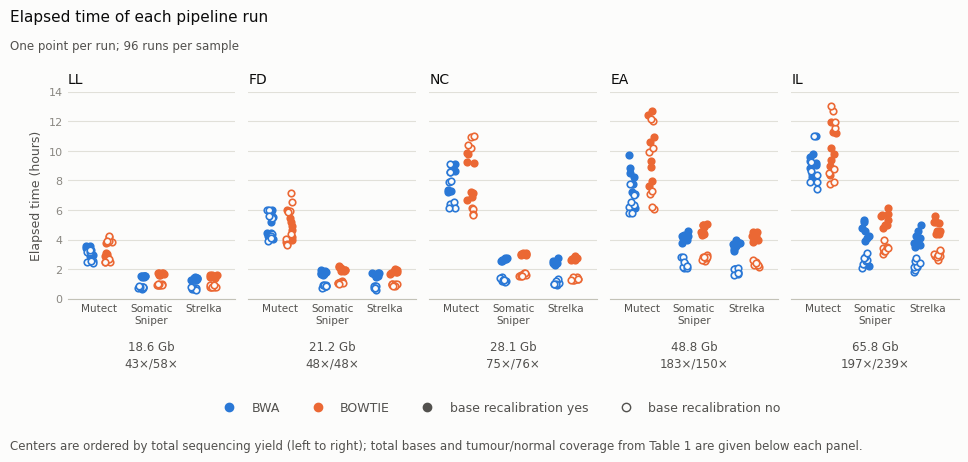

Mapper,BOWTIE,BWA
VariantCaller,,
Mutect,7.12,6.46
SomaticSniper,2.38,1.98
Strelka,2.05,1.70


In [53]:
fig, axes = viz.elapsed_time_strips(
    runs.reset_index(), samples=panel_order, panel_notes=panel_notes, caption=viz.YIELD_CAPTION,
    title="Elapsed time of each pipeline run",
    subtitle="One point per run; {} runs per sample".format(len(runs) // len(LEVELS["Sample"])))
# The figure must carry the trimming legend; without it an old swb.viz is loaded in this kernel
assert "Trimming, BaseRecalibration" in [lg.get_title().get_text() for lg in fig.legends], \
    "no trimming legend in the figure: restart the kernel (an old swb.viz is loaded)"
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "elapsed_time_by_run"))
plt.show()
# Table view: median elapsed hours by variant caller and mapper
(runs.pivot_table(index="VariantCaller", columns="Mapper", values="elapsed_seconds", aggfunc="median") / 3600).round(2)

## Parity check

Against the legacy time table `df_timeTable.csv` (480 rows), for every run:
- the settings, compute node and `ElapsedTime` string are equal;
- the two figure labels, `baseRecalibration, isTrimmed` and `Mapper, VariantCaller`, are equal;
- `elapsed_seconds` equals the parse the legacy figure used (`%H:%M:%S`).

The by-setting table and the Table 1 annotations under the figure panels are not in the legacy notebook and are reported as not compared. Results are moved out of staging only if every check that ran passes.

In [54]:
legacy = pd.read_csv(config.LEGACY_TIME_TABLE, dtype=str).set_index("TestCase")
ours = runs.set_index("TestCaseNo")

parity = audit.Parity()
parity.check("legacy df_timeTable.csv has the {} runs, once each".format(EXPECTED_RUNS),
             len(legacy) == EXPECTED_RUNS and legacy.index.is_unique and set(legacy.index) == set(ours.index),
             "{} rows".format(len(legacy)))
fields = ["Sample", "isTrimmed", "baseRecalibration", "Mapper", "VariantCaller", "Duplicates", "Node", "ElapsedTime",
          "Environment"]
differs = {c: int((ours[c].astype(str) != legacy[c].reindex(ours.index)).sum()) for c in fields}
differs = {c: n for c, n in differs.items() if n}
parity.check("settings, node and ElapsedTime == legacy df_timeTable ({} columns, every run)".format(len(fields)),
             not differs, differs)
labels = {"baseRecalibration, isTrimmed": ours["baseRecalibration"] + ", " + ours["isTrimmed"],  # the legacy label order
          "Mapper, VariantCaller": ours["Mapper"] + ", " + ours["VariantCaller"]}
differs = {k: int((v != legacy[k].reindex(ours.index)).sum()) for k, v in labels.items()}
differs = {k: n for k, n in differs.items() if n}
parity.check("figure labels 'baseRecalibration, isTrimmed' and 'Mapper, VariantCaller' == legacy", not differs, differs)
legacy_time = pd.to_datetime(legacy["ElapsedTime"], format="%H:%M:%S")
legacy_seconds = (legacy_time - legacy_time.dt.normalize()).dt.total_seconds()
n_equal = int((legacy_seconds.reindex(ours.index) == ours["elapsed_seconds"]).sum())
parity.check("elapsed_seconds == the legacy %H:%M:%S parse (every run)", n_equal == EXPECTED_RUNS,
             "{}/{} equal".format(n_equal, EXPECTED_RUNS))
parity.skip("elapsed_time_by_setting.csv ({} rows)".format(len(by_setting)),
            "not in the legacy notebook; computed from the verified time table")
parity.skip("sequencing yield and coverage under the figure panels",
            "from manuscript Table 1 (data/reference/sequencing_yield.csv), not derived from repository data; no legacy value")

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (4 checks, 2 skipped)
PASS  legacy df_timeTable.csv has the 480 runs, once each  [480 rows]
PASS  settings, node and ElapsedTime == legacy df_timeTable (9 columns, every run)  [{}]
PASS  figure labels 'baseRecalibration, isTrimmed' and 'Mapper, VariantCaller' == legacy  [{}]
PASS  elapsed_seconds == the legacy %H:%M:%S parse (every run)  [480/480 equal]
SKIP  elapsed_time_by_setting.csv (22 rows)  [not in the legacy notebook; computed from the verified time table]
SKIP  sequencing yield and coverage under the figure panels  [from manuscript Table 1 (data/reference/sequencing_yield.csv), not derived from repository data; no legacy value]



## Audit summary

In [55]:
hours = runs["elapsed_seconds"] / 3600
median_by_caller = (runs.groupby("VariantCaller")["elapsed_seconds"].median() / 3600).round(2)
lines = [
    "runs: {}; total elapsed time {:.0f} h; shortest {:.2f} h, longest {:.2f} h".format(
        len(runs), hours.sum(), hours.min(), hours.max()),
    "compute nodes: {} distinct; the node is not controlled, so comparisons by setting are descriptive".format(
        runs["Node"].nunique()),
    "elapsed_seconds parsed from H:MM:SS (all under 24 h); equal to the legacy parse for every run",
    "df_timeTable.csv reproduced for every run: {} columns and 2 figure labels".format(len(fields)),
    "not compared with legacy: elapsed_time_by_setting.csv (not in the legacy notebook)",
    "panel order (increasing total yield, manuscript Table 1): {}; annotations are not computed here".format(
        ", ".join(panel_order)),
    "median elapsed hours in that order: {}".format(
        (runs.groupby("Sample")["elapsed_seconds"].median().reindex(panel_order) / 3600).round(2).to_dict()),
    "",
    "median elapsed hours by variant caller: {}".format(median_by_caller.to_dict()),
    "median elapsed hours by {}: {}".format(
        TRIM_RECAL, (runs.groupby(TRIM_RECAL)["elapsed_seconds"].median() / 3600).round(2).to_dict()),
    "",
    "python {} | pandas {}".format(sys.version.split()[0], pd.__version__),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

runs: 480; total elapsed time 1827 h; shortest 0.58 h, longest 13.06 h
compute nodes: 83 distinct; the node is not controlled, so comparisons by setting are descriptive
elapsed_seconds parsed from H:MM:SS (all under 24 h); equal to the legacy parse for every run
df_timeTable.csv reproduced for every run: 9 columns and 2 figure labels
not compared with legacy: elapsed_time_by_setting.csv (not in the legacy notebook)
panel order (increasing total yield, manuscript Table 1): LL, FD, NC, EA, IL; annotations are not computed here
median elapsed hours in that order: {'LL': 1.51, 'FD': 1.81, 'NC': 2.67, 'EA': 4.24, 'IL': 4.68}

median elapsed hours by variant caller: {'Mutect': 6.76, 'SomaticSniper': 2.09, 'Strelka': 1.82}
median elapsed hours by isTrimmed, baseRecalibration: {'NO, NO': 2.23, 'NO, YES': 3.78, 'YES, NO': 2.46, 'YES, YES': 3.74}

python 3.8.12 | pandas 2.0.0


In [56]:
import inspect
print(viz.__file__)
print("isTrimmed" in inspect.getsource(viz.elapsed_time_strips))

/Users/guledaaydemir/Documents/Bioinformatics-StabilityAnalysis/somatic-wes-benchmark/src/swb/viz.py
True
